# PASYDA Pair-Level EDA

This notebook is written for the COMP7029 grooming detection project.

It does five practical jobs:

1. read the current PASYDA folder structure correctly
2. audit every scenario before modelling
3. build one pair-level sample for each suspect-contact pair
4. compare positive vs negative pairs using useful behavioural features
5. save report-ready tables and plots

The key idea is simple:

- the real machine learning sample is **not a single message row**
- the real sample is **one central node plus one contact node**
- each scenario should give **11 candidate pairs**
- exactly **1 pair** should be labelled positive


## Notebook Requirements

This notebook expects these Python packages in the notebook kernel:

- `pandas`
- `matplotlib`

The plain system `python` on this machine did not have `pandas` installed when this notebook was prepared, so if imports fail in your notebook, install the packages in the same Jupyter environment you plan to use.


In [2]:
import sys
print(sys.executable)

d:\RA_FAST_DLP\Eyecon_AI\eyecon-local-video-tester\.venv\Scripts\python.exe


In [3]:
from pathlib import Path
import warnings

try:
    import pandas as pd
    import matplotlib.pyplot as plt
except ImportError as exc:
    raise ImportError(
        "This notebook needs pandas and matplotlib in the active notebook environment."
    ) from exc

from IPython.display import display

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)


## Step 1: Point to the real dataset folders

The original short notebook expected ZIP extraction into a different path.
Here we read the folders exactly as they exist in this project:

- `PASYDA/Dataset/Dataset-1`
- `PASYDA/Dataset/Dataset-2`
- `PASYDA/Dataset/Dataset-3`
- `PASYDA/Dataset/Dataset-4`
- `PASYDA/Dataset/Dataset-5`

We also create an output folder so the plots and CSV summaries are easy to reuse in the report.


In [4]:
PROJECT_ROOT = Path.cwd()
DATASET_ROOT = PROJECT_ROOT / "PASYDA" / "Dataset"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "eda"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if not DATASET_ROOT.exists():
    raise FileNotFoundError(f"Dataset folder not found: {DATASET_ROOT}")

print("Project root :", PROJECT_ROOT)
print("Dataset root :", DATASET_ROOT)
print("Output folder:", OUTPUT_DIR)


Project root : d:\Kent Files\AI_Cyber\project
Dataset root : d:\Kent Files\AI_Cyber\project\PASYDA\Dataset
Output folder: d:\Kent Files\AI_Cyber\project\outputs\eda


In [5]:
def scenario_number(name):
    return int(name.replace("perp_", ""))


scenario_rows = []

for folder_path in sorted(DATASET_ROOT.glob("Dataset-*")):
    for vic_path in sorted(folder_path.glob("*_vic_data.csv"), key=lambda p: scenario_number(p.stem.replace("_vic_data", ""))):
        if vic_path.name.startswith("._"):
            continue

        scenario = vic_path.stem.replace("_vic_data", "")
        scenario_rows.append(
            {
                "folder": folder_path.name,
                "scenario": scenario,
                "data_path": folder_path / f"{scenario}_data.csv",
                "vic_path": vic_path,
                "solution_path": folder_path / f"{scenario}_solutions.csv",
            }
        )

scenario_index = pd.DataFrame(scenario_rows).sort_values(["folder", "scenario"]).reset_index(drop=True)
scenario_index.to_csv(OUTPUT_DIR / "scenario_index.csv", index=False)

print(f"Scenarios found: {len(scenario_index)}")
display(scenario_index)


Scenarios found: 10


,folder,scenario,data_path,vic_path,solution_path
0,Dataset-1,perp_0,d:\Kent Files\AI_Cyber\project\PASYDA\Dataset\...,d:\Kent Files\AI_Cyber\project\PASYDA\Dataset\...,d:\Kent Files\AI_Cyber\project\PASYDA\Dataset\...
1,Dataset-1,perp_1,d:\Kent Files\AI_Cyber\project\PASYDA\Dataset\...,d:\Kent Files\AI_Cyber\project\PASYDA\Dataset\...,d:\Kent Files\AI_Cyber\project\PASYDA\Dataset\...
2,Dataset-2,perp_2,d:\Kent Files\AI_Cyber\project\PASYDA\Dataset\...,d:\Kent Files\AI_Cyber\project\PASYDA\Dataset\...,d:\Kent Files\AI_Cyber\project\PASYDA\Dataset\...
3,Dataset-2,perp_3,d:\Kent Files\AI_Cyber\project\PASYDA\Dataset\...,d:\Kent Files\AI_Cyber\project\PASYDA\Dataset\...,d:\Kent Files\AI_Cyber\project\PASYDA\Dataset\...
4,Dataset-3,perp_4,d:\Kent Files\AI_Cyber\project\PASYDA\Dataset\...,d:\Kent Files\AI_Cyber\project\PASYDA\Dataset\...,d:\Kent Files\AI_Cyber\project\PASYDA\Dataset\...
5,Dataset-3,perp_5,d:\Kent Files\AI_Cyber\project\PASYDA\Dataset\...,d:\Kent Files\AI_Cyber\project\PASYDA\Dataset\...,d:\Kent Files\AI_Cyber\project\PASYDA\Dataset\...
6,Dataset-4,perp_6,d:\Kent Files\AI_Cyber\project\PASYDA\Dataset\...,d:\Kent Files\AI_Cyber\project\PASYDA\Dataset\...,d:\Kent Files\AI_Cyber\project\PASYDA\Dataset\...
7,Dataset-4,perp_7,d:\Kent Files\AI_Cyber\project\PASYDA\Dataset\...,d:\Kent Files\AI_Cyber\project\PASYDA\Dataset\...,d:\Kent Files\AI_Cyber\project\PASYDA\Dataset\...
8,Dataset-5,perp_8,d:\Kent Files\AI_Cyber\project\PASYDA\Dataset\...,d:\Kent Files\AI_Cyber\project\PASYDA\Dataset\...,d:\Kent Files\AI_Cyber\project\PASYDA\Dataset\...
9,Dataset-5,perp_9,d:\Kent Files\AI_Cyber\project\PASYDA\Dataset\...,d:\Kent Files\AI_Cyber\project\PASYDA\Dataset\...,d:\Kent Files\AI_Cyber\project\PASYDA\Dataset\...


## Step 2: Helper functions

These functions keep the later cells short and easy to follow.

- `pair_key()` makes an undirected pair label
- `load_scenario_tables()` loads one scenario cleanly
- `find_central_node()` finds the node that appears in every victim-network interaction
- `safe_ratio()` prevents divide-by-zero problems


In [6]:
EXPECTED_COLUMNS = {"ID", "Source", "Destination", "Date", "Length"}


def pair_key(node_a, node_b):
    return "|".join(sorted([str(node_a), str(node_b)]))


def safe_ratio(numerator, denominator):
    return float(numerator) / float(denominator) if denominator else 0.0


def load_scenario_tables(row):
    data_df = pd.read_csv(row.data_path).copy()
    vic_df = pd.read_csv(row.vic_path).copy()
    sol_df = pd.read_csv(row.solution_path).copy()

    for df in (data_df, vic_df, sol_df):
        missing_columns = EXPECTED_COLUMNS.difference(df.columns)
        if missing_columns:
            raise ValueError(f"Missing columns {missing_columns} in scenario {row.scenario}")

        df["Date"] = pd.to_datetime(df["Date"])
        df["Length"] = pd.to_numeric(df["Length"], errors="coerce")

    return data_df, vic_df, sol_df


def find_central_node(vic_df):
    nodes = sorted(set(vic_df["Source"]).union(vic_df["Destination"]))
    central_candidates = [
        node for node in nodes
        if ((vic_df["Source"] == node) | (vic_df["Destination"] == node)).all()
    ]

    if len(central_candidates) != 1:
        raise ValueError(
            f"Expected exactly 1 central node, but found {len(central_candidates)} candidates: {central_candidates}"
        )

    return central_candidates[0]


## Step 3: Audit every scenario

Before any modelling or feature engineering, we verify that the dataset structure matches the project assumptions.

We check:

- `solutions` rows are inside `vic_data`
- `vic_data` rows are inside `data`
- every `vic_data` file has one central node
- the victim network has 12 unique nodes
- the victim network gives 11 candidate pairs
- the solution file maps to 1 positive pair


In [7]:
audit_rows = []

for row in scenario_index.itertuples(index=False):
    data_df, vic_df, sol_df = load_scenario_tables(row)
    central_node = find_central_node(vic_df)

    vic_pair_keys = vic_df.apply(lambda r: pair_key(r["Source"], r["Destination"]), axis=1)
    sol_pair_keys = sol_df.apply(lambda r: pair_key(r["Source"], r["Destination"]), axis=1)

    audit_rows.append(
        {
            "folder": row.folder,
            "scenario": row.scenario,
            "data_rows": len(data_df),
            "vic_rows": len(vic_df),
            "solution_rows": len(sol_df),
            "solutions_inside_vic": sol_df["ID"].isin(vic_df["ID"]).all(),
            "vic_inside_data": vic_df["ID"].isin(data_df["ID"]).all(),
            "unique_nodes_in_vic": len(set(vic_df["Source"]).union(vic_df["Destination"])),
            "central_node": central_node,
            "central_node_in_every_row": ((vic_df["Source"] == central_node) | (vic_df["Destination"] == central_node)).all(),
            "candidate_pairs": vic_pair_keys.nunique(),
            "positive_pairs": sol_pair_keys.nunique(),
            "missing_values_in_vic": int(vic_df.isna().sum().sum()),
            "start_time": vic_df["Date"].min(),
            "end_time": vic_df["Date"].max(),
        }
    )

audit_df = pd.DataFrame(audit_rows).sort_values(["folder", "scenario"]).reset_index(drop=True)
audit_df.to_csv(OUTPUT_DIR / "scenario_audit.csv", index=False)

display(audit_df)

assert audit_df["solutions_inside_vic"].all(), "Some solutions rows are not inside vic_data."
assert audit_df["vic_inside_data"].all(), "Some vic_data rows are not inside data."
assert audit_df["central_node_in_every_row"].all(), "At least one scenario does not have a valid central node."
assert (audit_df["unique_nodes_in_vic"] == 12).all(), "Expected 12 nodes in each vic_data file."
assert (audit_df["candidate_pairs"] == 11).all(), "Expected 11 candidate pairs per scenario."
assert (audit_df["positive_pairs"] == 1).all(), "Expected exactly 1 positive pair per scenario."

print("All structural checks passed.")


,folder,scenario,data_rows,vic_rows,solution_rows,solutions_inside_vic,vic_inside_data,unique_nodes_in_vic,central_node,central_node_in_every_row,candidate_pairs,positive_pairs,missing_values_in_vic,start_time,end_time
0,Dataset-1,perp_0,566770,3512,588,True,True,12,220.63.8.62,True,11,1,0,2008-03-09 14:15:15,2008-03-31 19:53:49
1,Dataset-1,perp_1,420077,2427,246,True,True,12,208.145.72.7,True,11,1,0,2009-09-14 23:15:15,2009-10-01 23:59:51
2,Dataset-2,perp_2,924316,5387,571,True,True,12,211.126.63.60,True,11,1,0,2009-09-14 16:15:15,2009-10-20 19:28:27
3,Dataset-2,perp_3,977404,5664,533,True,True,12,143.62.207.101,True,11,1,0,2008-02-25 17:15:15,2008-04-04 00:37:35
4,Dataset-3,perp_4,773107,4063,175,True,True,12,58.12.70.0,True,11,1,0,2008-09-26 02:15:15,2008-10-26 04:26:09
5,Dataset-3,perp_5,1205893,7430,724,True,True,12,37.173.66.63,True,11,1,0,2008-01-19 13:15:15,2008-03-06 20:50:45
6,Dataset-4,perp_6,2025600,11654,588,True,True,12,38.237.149.58,True,11,1,0,2008-01-20 16:15:15,2008-04-08 22:10:02
7,Dataset-4,perp_7,1461470,9452,957,True,True,12,130.1.207.110,True,11,1,0,2008-06-18 13:15:15,2008-08-14 16:02:56
8,Dataset-5,perp_8,387410,2517,565,True,True,12,109.245.208.104,True,11,1,0,2008-06-18 14:15:15,2008-07-03 20:55:21
9,Dataset-5,perp_9,514400,3474,737,True,True,12,21.134.179.200,True,11,1,0,2008-09-15 15:15:15,2008-10-05 22:55:22


All structural checks passed.


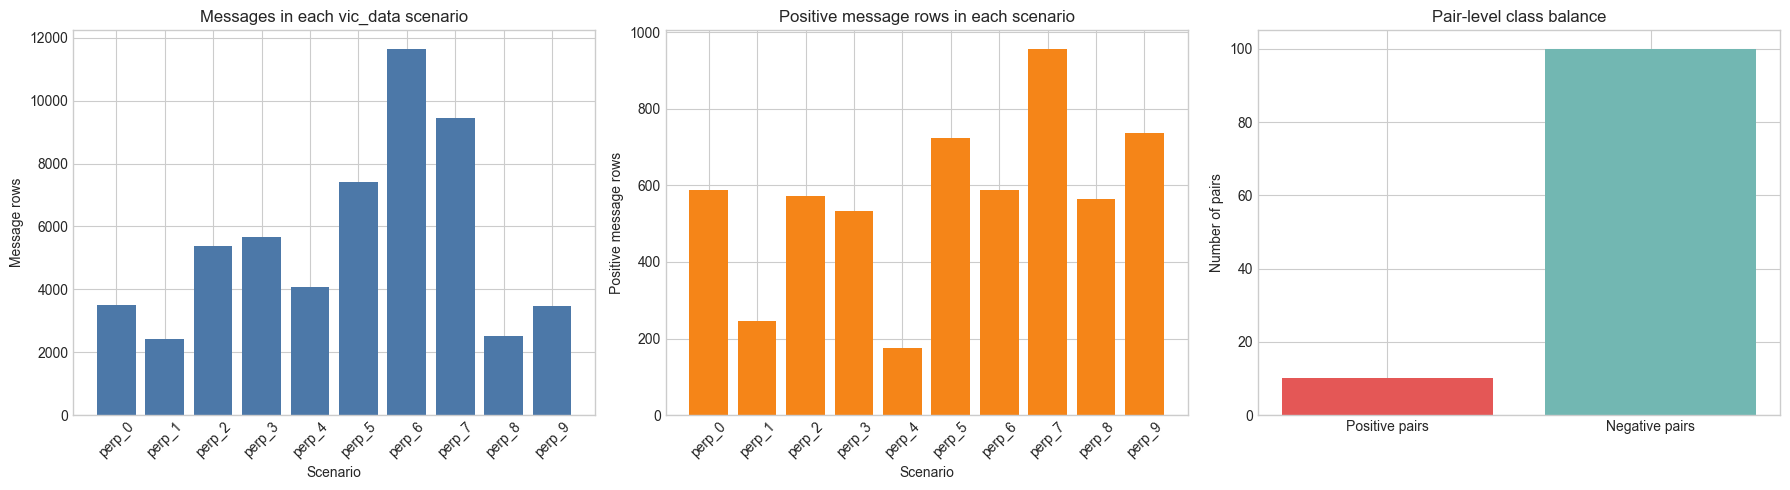

In [8]:
pair_balance = pd.Series(
    {
        "Positive pairs": int(audit_df["positive_pairs"].sum()),
        "Negative pairs": int(audit_df["candidate_pairs"].sum() - audit_df["positive_pairs"].sum()),
    }
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(audit_df["scenario"], audit_df["vic_rows"], color="#4C78A8")
axes[0].set_title("Messages in each vic_data scenario")
axes[0].set_xlabel("Scenario")
axes[0].set_ylabel("Message rows")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(audit_df["scenario"], audit_df["solution_rows"], color="#F58518")
axes[1].set_title("Positive message rows in each scenario")
axes[1].set_xlabel("Scenario")
axes[1].set_ylabel("Positive message rows")
axes[1].tick_params(axis="x", rotation=45)

axes[2].bar(pair_balance.index, pair_balance.values, color=["#E45756", "#72B7B2"])
axes[2].set_title("Pair-level class balance")
axes[2].set_ylabel("Number of pairs")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_dataset_overview.png", dpi=200, bbox_inches="tight")
plt.show()


## Step 4: Build pair-level samples

This is the most important step in the notebook.

For each scenario we:

- find the central node
- list the 11 contact nodes
- create one row per central-contact pair
- label the true solution pair as `1`
- label the other 10 pairs as `0`

We then compute features that are useful for EDA and later modelling:

- message count
- direction balance
- reciprocity
- conversation duration
- message length statistics
- message timing features
- gap and burst features


In [9]:
def build_pair_level_features(row):
    _, vic_df, sol_df = load_scenario_tables(row)
    central_node = find_central_node(vic_df)

    positive_pair_keys = sol_df.apply(lambda r: pair_key(r["Source"], r["Destination"]), axis=1).unique()
    if len(positive_pair_keys) != 1:
        raise ValueError(f"Scenario {row.scenario} should map to exactly one positive pair.")

    positive_pair_key = positive_pair_keys[0]
    contact_nodes = sorted(node for node in set(vic_df["Source"]).union(vic_df["Destination"]) if node != central_node)
    scenario_message_total = len(vic_df)

    pair_rows = []

    for contact_node in contact_nodes:
        mask = (
            ((vic_df["Source"] == central_node) & (vic_df["Destination"] == contact_node))
            | ((vic_df["Source"] == contact_node) & (vic_df["Destination"] == central_node))
        )

        pair_df = vic_df.loc[mask].sort_values("Date").copy()
        pair_df["hour"] = pair_df["Date"].dt.hour
        pair_df["day_of_week"] = pair_df["Date"].dt.dayofweek

        outgoing_count = int(((pair_df["Source"] == central_node) & (pair_df["Destination"] == contact_node)).sum())
        incoming_count = int(((pair_df["Source"] == contact_node) & (pair_df["Destination"] == central_node)).sum())

        gaps_in_seconds = pair_df["Date"].diff().dt.total_seconds().dropna()
        duration_hours = safe_ratio(
            (pair_df["Date"].max() - pair_df["Date"].min()).total_seconds(),
            3600,
        ) if len(pair_df) > 1 else 0.0

        pair_rows.append(
            {
                "folder": row.folder,
                "scenario": row.scenario,
                "central_node": central_node,
                "contact_node": contact_node,
                "pair_key": pair_key(central_node, contact_node),
                "label": int(pair_key(central_node, contact_node) == positive_pair_key),
                "message_count": len(pair_df),
                "central_to_contact": outgoing_count,
                "contact_to_central": incoming_count,
                "sent_ratio": safe_ratio(outgoing_count, len(pair_df)),
                "received_ratio": safe_ratio(incoming_count, len(pair_df)),
                "reciprocity_ratio": safe_ratio(min(outgoing_count, incoming_count), max(outgoing_count, incoming_count)),
                "message_share_in_scenario": safe_ratio(len(pair_df), scenario_message_total),
                "first_message": pair_df["Date"].min(),
                "last_message": pair_df["Date"].max(),
                "duration_hours": duration_hours,
                "active_days": pair_df["Date"].dt.normalize().nunique(),
                "mean_length": pair_df["Length"].mean(),
                "median_length": pair_df["Length"].median(),
                "std_length": pair_df["Length"].std(ddof=0),
                "min_length": pair_df["Length"].min(),
                "max_length": pair_df["Length"].max(),
                "mean_gap_minutes": safe_ratio(gaps_in_seconds.mean(), 60) if not gaps_in_seconds.empty else 0.0,
                "median_gap_minutes": safe_ratio(gaps_in_seconds.median(), 60) if not gaps_in_seconds.empty else 0.0,
                "std_gap_minutes": safe_ratio(gaps_in_seconds.std(ddof=0), 60) if not gaps_in_seconds.empty else 0.0,
                "bursty_gap_ratio": float((gaps_in_seconds <= 300).mean()) if not gaps_in_seconds.empty else 0.0,
                "night_ratio": float(pair_df["hour"].isin([0, 1, 2, 3, 4, 5, 6]).mean()),
                "evening_ratio": float(pair_df["hour"].isin([18, 19, 20, 21, 22, 23]).mean()),
                "weekend_ratio": float(pair_df["day_of_week"].isin([5, 6]).mean()),
            }
        )

    return pd.DataFrame(pair_rows)


pair_level_df = pd.concat(
    [build_pair_level_features(row) for row in scenario_index.itertuples(index=False)],
    ignore_index=True,
).sort_values(["folder", "scenario", "contact_node"]).reset_index(drop=True)

pair_level_df["label_name"] = pair_level_df["label"].map({0: "Negative pair", 1: "Positive pair"})
pair_level_df.to_csv(OUTPUT_DIR / "pair_level_features.csv", index=False)

print("Pair-level shape:", pair_level_df.shape)
display(pair_level_df.head(15))


Pair-level shape: (110, 30)


,folder,scenario,central_node,contact_node,pair_key,label,message_count,central_to_contact,contact_to_central,sent_ratio,received_ratio,reciprocity_ratio,message_share_in_scenario,first_message,last_message,duration_hours,active_days,mean_length,median_length,std_length,min_length,max_length,mean_gap_minutes,median_gap_minutes,std_gap_minutes,bursty_gap_ratio,night_ratio,evening_ratio,weekend_ratio,label_name
0,Dataset-1,perp_0,220.63.8.62,115.61.225.89,115.61.225.89|220.63.8.62,0,310,160,150,0.516129,0.483871,0.937500,0.088269,2008-03-11 17:39:44,2008-03-27 14:14:00,380.571111,9,54.016129,46.0,38.841154,1,243,73.897303,0.333333,583.023561,0.967638,0.000000,0.293548,0.351613,Negative pair
1,Dataset-1,perp_0,220.63.8.62,135.24.98.94,135.24.98.94|220.63.8.62,0,118,63,55,0.533898,0.466102,0.873016,0.033599,2008-03-11 16:15:57,2008-03-25 19:04:37,338.811111,3,55.779661,47.5,36.682591,3,196,173.749288,0.333333,1746.656174,0.982906,0.000000,0.381356,0.000000,Negative pair
2,Dataset-1,perp_0,220.63.8.62,14.62.127.28,14.62.127.28|220.63.8.62,0,230,115,115,0.500000,0.500000,1.000000,0.065490,2008-03-17 14:56:13,2008-03-29 19:15:11,292.316111,4,50.921739,47.0,33.978548,2,180,76.589374,0.333333,768.852270,0.986900,0.000000,0.495652,0.047826,Negative pair
3,Dataset-1,perp_0,220.63.8.62,156.43.42.60,156.43.42.60|220.63.8.62,0,365,191,174,0.523288,0.476712,0.910995,0.103929,2008-03-09 14:15:15,2008-03-31 19:53:49,533.642778,6,51.852055,42.0,36.501305,2,193,87.963095,0.283333,860.522017,0.980769,0.000000,0.079452,0.115068,Negative pair
4,Dataset-1,perp_0,220.63.8.62,189.148.12.135,189.148.12.135|220.63.8.62,0,136,71,65,0.522059,0.477941,0.915493,0.038724,2008-03-12 17:28:14,2008-03-16 18:04:29,96.604167,3,48.529412,36.0,36.517711,0,205,42.935185,0.283333,377.498328,0.970370,0.000000,0.073529,0.852941,Negative pair
5,Dataset-1,perp_0,220.63.8.62,189.238.4.154,189.238.4.154|220.63.8.62,0,123,65,58,0.528455,0.471545,0.892308,0.035023,2008-03-13 14:17:34,2008-03-30 17:21:35,411.066944,4,51.138211,47.0,34.604461,4,197,202.164071,0.341667,1835.010658,0.967213,0.056911,0.000000,0.902439,Negative pair
6,Dataset-1,perp_0,220.63.8.62,217.200.101.232,217.200.101.232|220.63.8.62,0,187,97,90,0.518717,0.481283,0.927835,0.053246,2008-03-09 14:48:46,2008-03-26 16:52:30,410.062222,7,55.802139,48.0,37.582542,3,216,132.278136,0.350000,892.401493,0.967742,0.000000,0.053476,0.513369,Negative pair
7,Dataset-1,perp_0,220.63.8.62,47.238.189.27,220.63.8.62|47.238.189.27,0,1117,567,550,0.507610,0.492390,0.970018,0.318052,2008-03-12 15:14:18,2008-03-31 15:21:38,456.122222,10,53.184423,45.0,38.678252,1,291,24.522700,0.316667,318.660965,0.989247,0.000000,0.065354,0.065354,Negative pair
8,Dataset-1,perp_0,220.63.8.62,82.10.101.74,220.63.8.62|82.10.101.74,0,184,85,99,0.461957,0.538043,0.858586,0.052392,2008-03-12 15:11:17,2008-03-29 16:45:42,409.573611,4,54.597826,47.5,35.450075,5,174,134.286430,0.333333,1503.039589,0.983607,0.000000,0.000000,0.217391,Negative pair
9,Dataset-1,perp_0,220.63.8.62,9.197.150.82,220.63.8.62|9.197.150.82,0,154,76,78,0.493506,0.506494,0.974359,0.043850,2008-03-15 14:43:59,2008-03-23 17:18:26,194.574167,4,52.084416,42.5,35.897392,6,178,76.303595,0.300000,545.970014,0.980392,0.000000,0.000000,0.324675,Negative pair


In [10]:
label_check = (
    pair_level_df.groupby(["folder", "scenario"], as_index=False)
    .agg(total_pairs=("pair_key", "count"), positive_pairs=("label", "sum"))
    .sort_values(["folder", "scenario"])
)

label_check.to_csv(OUTPUT_DIR / "pair_level_label_check.csv", index=False)
display(label_check)

assert (label_check["total_pairs"] == 11).all(), "Every scenario should create 11 pair-level samples."
assert (label_check["positive_pairs"] == 1).all(), "Every scenario should create exactly 1 positive pair."

print("Pair-level label checks passed.")


,folder,scenario,total_pairs,positive_pairs
0,Dataset-1,perp_0,11,1
1,Dataset-1,perp_1,11,1
2,Dataset-2,perp_2,11,1
3,Dataset-2,perp_3,11,1
4,Dataset-3,perp_4,11,1
5,Dataset-3,perp_5,11,1
6,Dataset-4,perp_6,11,1
7,Dataset-4,perp_7,11,1
8,Dataset-5,perp_8,11,1
9,Dataset-5,perp_9,11,1


Pair-level label checks passed.


## Step 5: Compare positive vs negative pairs

Now we compare the two classes using features that make sense for this project.

The goal here is not to prove causation.
The goal is to see whether positive and negative pairs show **different behavioural patterns** that can later help feature engineering and model design.


In [11]:
metrics_to_compare = [
    "message_count",
    "duration_hours",
    "reciprocity_ratio",
    "mean_length",
    "median_length",
    "night_ratio",
    "evening_ratio",
    "weekend_ratio",
    "mean_gap_minutes",
    "bursty_gap_ratio",
    "message_share_in_scenario",
]

comparison_mean = (
    pair_level_df.groupby("label_name")[metrics_to_compare]
    .mean()
    .T
    .rename_axis("feature")
    .round(3)
)

comparison_median = (
    pair_level_df.groupby("label_name")[metrics_to_compare]
    .median()
    .T
    .rename_axis("feature")
    .round(3)
)

comparison_summary = comparison_mean.join(
    comparison_median,
    lsuffix="_mean",
    rsuffix="_median",
)

comparison_summary.to_csv(OUTPUT_DIR / "feature_comparison_by_label.csv")
display(comparison_summary)


label_name,Negative pair_mean,Positive pair_mean,Negative pair_median,Positive pair_median
feature,,,,
message_count,498.960,568.400,308.500,579.500
duration_hours,696.838,817.551,647.048,662.081
reciprocity_ratio,0.944,0.842,0.958,0.873
mean_length,52.647,20.903,52.682,19.581
median_length,44.580,16.500,44.500,15.500
night_ratio,0.167,0.266,0.000,0.163
evening_ratio,0.284,0.586,0.146,0.717
weekend_ratio,0.277,0.186,0.195,0.163
mean_gap_minutes,106.498,92.868,102.014,90.511


In [12]:
insight_rows = []

for metric in metrics_to_compare:
    positive_mean = pair_level_df.loc[pair_level_df["label"] == 1, metric].mean()
    negative_mean = pair_level_df.loc[pair_level_df["label"] == 0, metric].mean()
    difference = positive_mean - negative_mean

    insight_rows.append(
        {
            "feature": metric,
            "positive_mean": round(positive_mean, 4),
            "negative_mean": round(negative_mean, 4),
            "difference": round(difference, 4),
            "absolute_difference": round(abs(difference), 4),
        }
    )

insight_df = pd.DataFrame(insight_rows).sort_values("absolute_difference", ascending=False).reset_index(drop=True)
insight_df.to_csv(OUTPUT_DIR / "feature_gaps_ranked.csv", index=False)

display(insight_df)


,feature,positive_mean,negative_mean,difference,absolute_difference
0,duration_hours,817.5513,696.8378,120.7135,120.7135
1,message_count,568.4000,498.9600,69.4400,69.4400
2,mean_length,20.9027,52.6469,-31.7442,31.7442
3,median_length,16.5000,44.5800,-28.0800,28.0800
4,mean_gap_minutes,92.8679,106.4980,-13.6300,13.6300
5,evening_ratio,0.5859,0.2837,0.3022,0.3022
6,reciprocity_ratio,0.8420,0.9440,-0.1020,0.1020
7,night_ratio,0.2664,0.1673,0.0991,0.0991
8,weekend_ratio,0.1861,0.2769,-0.0908,0.0908
9,message_share_in_scenario,0.1198,0.0880,0.0317,0.0317


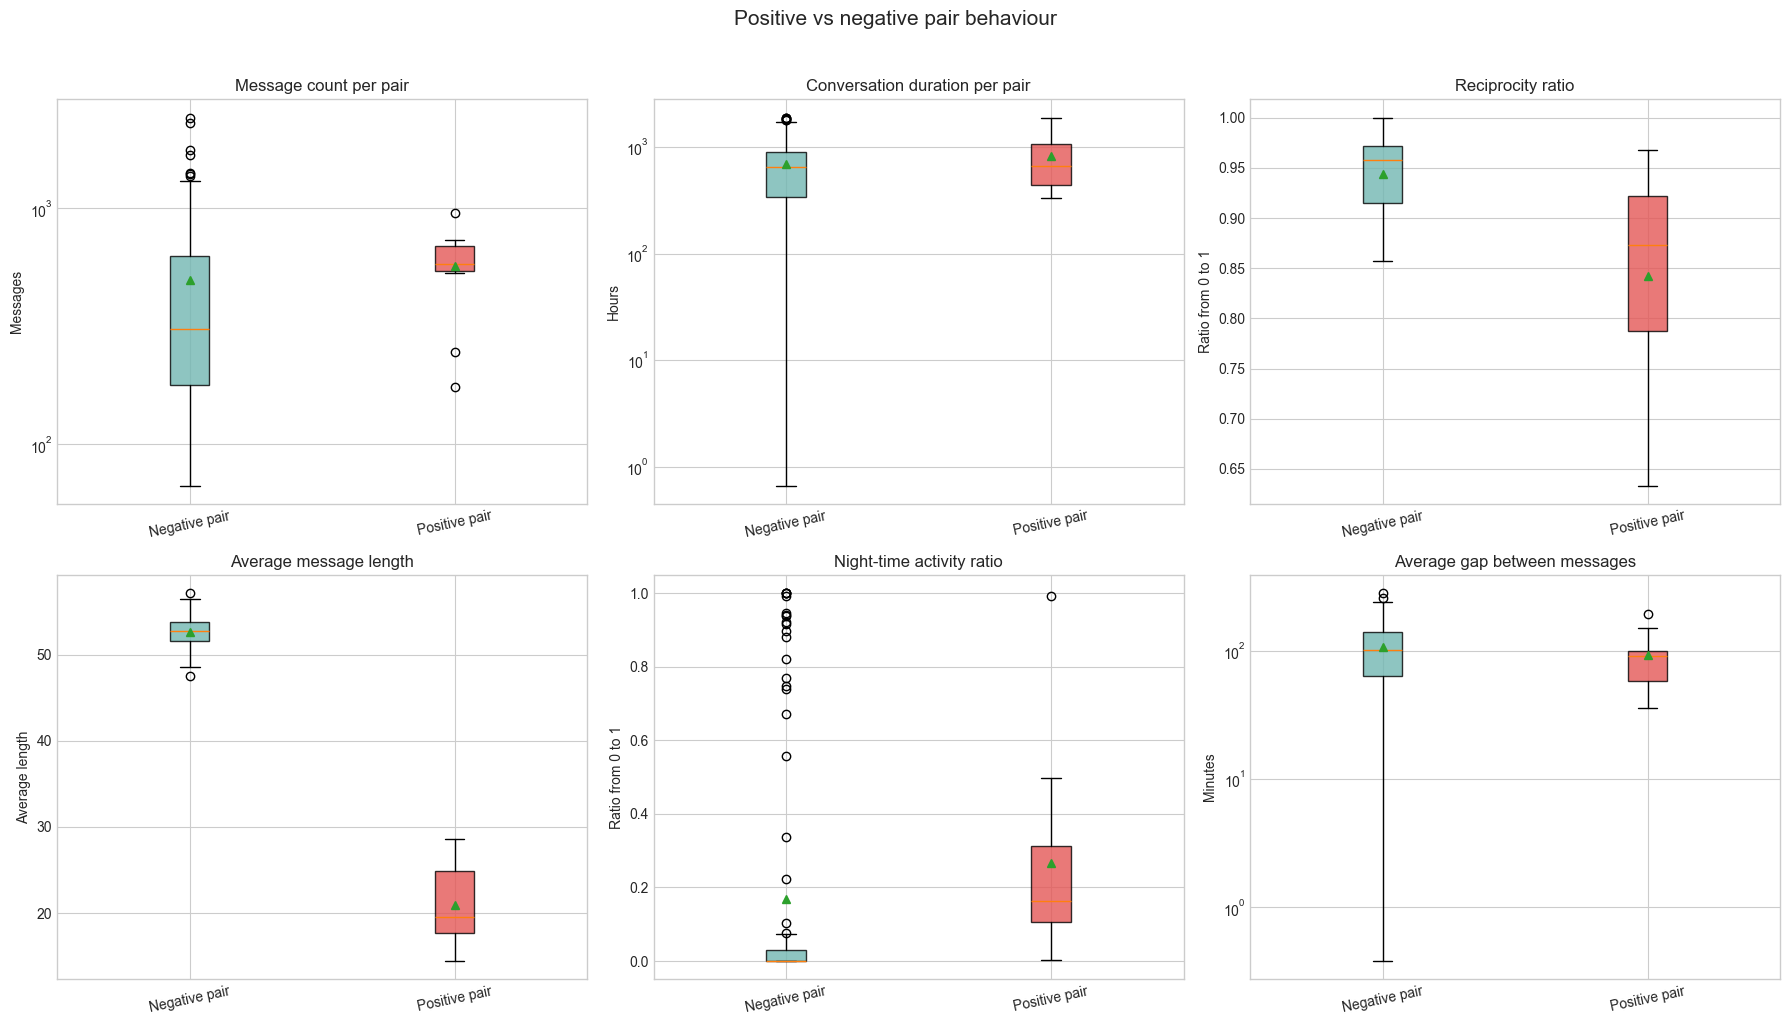

In [13]:
label_order = ["Negative pair", "Positive pair"]
box_colors = ["#72B7B2", "#E45756"]


def draw_boxplot(ax, column, title, ylabel, log_scale=False):
    values = [
        pair_level_df.loc[pair_level_df["label_name"] == label, column].dropna()
        for label in label_order
    ]

    plot = ax.boxplot(values, labels=label_order, patch_artist=True, showmeans=True)

    for patch, color in zip(plot["boxes"], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.80)

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=12)

    if log_scale:
        ax.set_yscale("log")


fig, axes = plt.subplots(2, 3, figsize=(18, 10))

draw_boxplot(axes[0, 0], "message_count", "Message count per pair", "Messages", log_scale=True)
draw_boxplot(axes[0, 1], "duration_hours", "Conversation duration per pair", "Hours", log_scale=True)
draw_boxplot(axes[0, 2], "reciprocity_ratio", "Reciprocity ratio", "Ratio from 0 to 1")
draw_boxplot(axes[1, 0], "mean_length", "Average message length", "Average length")
draw_boxplot(axes[1, 1], "night_ratio", "Night-time activity ratio", "Ratio from 0 to 1")
draw_boxplot(axes[1, 2], "mean_gap_minutes", "Average gap between messages", "Minutes", log_scale=True)

plt.suptitle("Positive vs negative pair behaviour", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_positive_vs_negative_boxplots.png", dpi=200, bbox_inches="tight")
plt.show()


## Step 6: Check whether simple heuristics are enough

A good project insight is not only "which features are bigger or smaller".
We also want to know whether a simple rule would already solve the task.

Below we rank the true positive pair inside each scenario by a few simple metrics.

If the positive pair is not always rank 1, that tells us a model needs more than one easy heuristic.


In [14]:
rank_df = pair_level_df.copy()
rank_df["rank_by_message_count"] = rank_df.groupby("scenario")["message_count"].rank(ascending=False, method="min")
rank_df["rank_by_duration"] = rank_df.groupby("scenario")["duration_hours"].rank(ascending=False, method="min")
rank_df["rank_by_reciprocity"] = rank_df.groupby("scenario")["reciprocity_ratio"].rank(ascending=False, method="min")

positive_rank_df = (
    rank_df.loc[rank_df["label"] == 1, ["folder", "scenario", "rank_by_message_count", "rank_by_duration", "rank_by_reciprocity"]]
    .sort_values(["folder", "scenario"])
    .reset_index(drop=True)
)

positive_rank_df.to_csv(OUTPUT_DIR / "positive_pair_ranks.csv", index=False)
display(positive_rank_df)


,folder,scenario,rank_by_message_count,rank_by_duration,rank_by_reciprocity
0,Dataset-1,perp_0,2.0,2.0,11.0
1,Dataset-1,perp_1,3.0,1.0,4.0
2,Dataset-2,perp_2,3.0,3.0,10.0
3,Dataset-2,perp_3,4.0,3.0,11.0
4,Dataset-3,perp_4,9.0,10.0,11.0
5,Dataset-3,perp_5,4.0,2.0,9.0
6,Dataset-4,perp_6,9.0,1.0,11.0
7,Dataset-4,perp_7,4.0,1.0,10.0
8,Dataset-5,perp_8,2.0,2.0,9.0
9,Dataset-5,perp_9,2.0,2.0,11.0


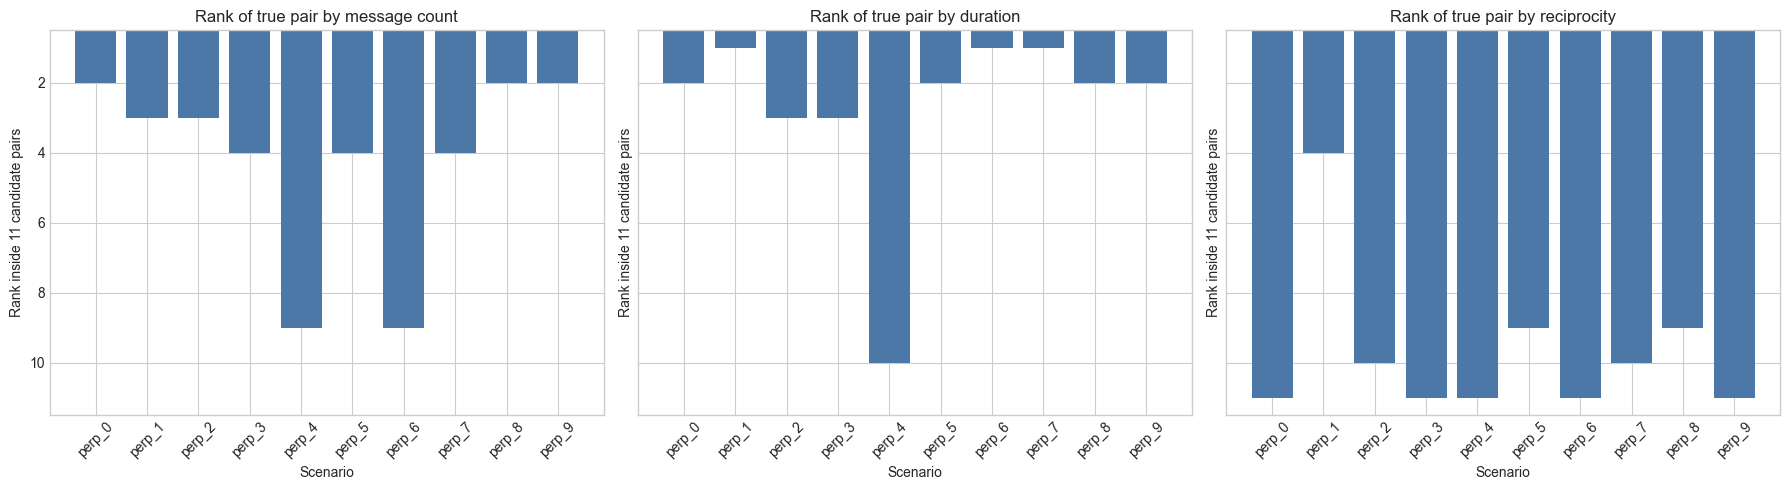

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
rank_columns = [
    ("rank_by_message_count", "Rank of true pair by message count"),
    ("rank_by_duration", "Rank of true pair by duration"),
    ("rank_by_reciprocity", "Rank of true pair by reciprocity"),
]

for ax, (column, title) in zip(axes, rank_columns):
    ax.bar(positive_rank_df["scenario"], positive_rank_df[column], color="#4C78A8")
    ax.set_title(title)
    ax.set_xlabel("Scenario")
    ax.set_ylabel("Rank inside 11 candidate pairs")
    ax.set_ylim(11.5, 0.5)
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_positive_pair_ranks.png", dpi=200, bbox_inches="tight")
plt.show()


## Step 7: Save a short report-friendly summary

This final cell prints a compact summary that is useful when writing the EDA section of the report.


In [16]:
positive_pairs = int(pair_level_df["label"].sum())
negative_pairs = int((pair_level_df["label"] == 0).sum())

print("=" * 70)
print("PASYDA PAIR-LEVEL EDA SUMMARY")
print("=" * 70)
print(f"Scenarios analysed           : {len(scenario_index)}")
print(f"Dataset folders analysed     : {scenario_index['folder'].nunique()}")
print(f"Pair-level samples created   : {len(pair_level_df)}")
print(f"Positive pairs               : {positive_pairs}")
print(f"Negative pairs               : {negative_pairs}")
print(f"Pair-level positive rate     : {positive_pairs / len(pair_level_df):.2%}")
print()
print("Saved outputs")
print(f"- Scenario index             : {OUTPUT_DIR / 'scenario_index.csv'}")
print(f"- Scenario audit             : {OUTPUT_DIR / 'scenario_audit.csv'}")
print(f"- Pair-level features        : {OUTPUT_DIR / 'pair_level_features.csv'}")
print(f"- Label check                : {OUTPUT_DIR / 'pair_level_label_check.csv'}")
print(f"- Feature comparison table   : {OUTPUT_DIR / 'feature_comparison_by_label.csv'}")
print(f"- Ranked feature gaps        : {OUTPUT_DIR / 'feature_gaps_ranked.csv'}")
print(f"- Positive pair ranks        : {OUTPUT_DIR / 'positive_pair_ranks.csv'}")
print(f"- Plot 1                     : {OUTPUT_DIR / '01_dataset_overview.png'}")
print(f"- Plot 2                     : {OUTPUT_DIR / '02_positive_vs_negative_boxplots.png'}")
print(f"- Plot 3                     : {OUTPUT_DIR / '03_positive_pair_ranks.png'}")


PASYDA PAIR-LEVEL EDA SUMMARY
Scenarios analysed           : 10
Dataset folders analysed     : 5
Pair-level samples created   : 110
Positive pairs               : 10
Negative pairs               : 100
Pair-level positive rate     : 9.09%

Saved outputs
- Scenario index             : d:\Kent Files\AI_Cyber\project\outputs\eda\scenario_index.csv
- Scenario audit             : d:\Kent Files\AI_Cyber\project\outputs\eda\scenario_audit.csv
- Pair-level features        : d:\Kent Files\AI_Cyber\project\outputs\eda\pair_level_features.csv
- Label check                : d:\Kent Files\AI_Cyber\project\outputs\eda\pair_level_label_check.csv
- Feature comparison table   : d:\Kent Files\AI_Cyber\project\outputs\eda\feature_comparison_by_label.csv
- Ranked feature gaps        : d:\Kent Files\AI_Cyber\project\outputs\eda\feature_gaps_ranked.csv
- Positive pair ranks        : d:\Kent Files\AI_Cyber\project\outputs\eda\positive_pair_ranks.csv
- Plot 1                     : d:\Kent Files\AI_Cyber\projec